In [44]:
import os
import time
import requests
from bs4 import BeautifulSoup

import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  # 設定黑體（SimHei）支援中文
plt.rcParams['axes.unicode_minus'] = False    # 正確顯示負號


In [45]:
url = 'https://bottleneko.app/series'
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}
download_folder = 'series'
os.makedirs(download_folder, exist_ok=True)
img_urls = []

In [46]:
# 多個 class 請用 set 傳入
target_classes = set([
    "flex-none", "p-0", "md:p-4", "rounded-xl", "md:bg-zinc-900", "md:hover:bg-zinc-800",
    "will-change-[background]", "transition-colors", "cursor-pointer", "min-w-[8rem]",
    "max-h-[25rem]", "w-full", "h-full", "snap-center", "flex", "flex-col"
])

In [47]:
try:
    time.sleep(1.5)
    response = requests.get(url, headers=headers, timeout=10)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, 'html.parser')

    # 搜尋所有符合多個 class 的區塊
    containers = soup.find_all(lambda tag: tag.name == "div" and target_classes.issubset(set(tag.get("class", []))))
    print(f"找到 {len(containers)} 個目標區塊")

    for container in containers:
        # 找到圖片
        img_tag = container.find('img')
        # 找到標題文字
        title_tag = container.find('p', class_="pb-1 text-sm md:text-base font-normal md:font-bold !text-white truncate")
        if img_tag and title_tag:
            img_url = img_tag.get('src')
            title = title_tag.get_text(strip=True)
            # 處理檔名中的非法字元
            safe_title = "".join([c for c in title if c.isalnum() or c in " _-"]).rstrip()
            if img_url:
                if img_url.startswith('//'):
                    img_url = 'https:' + img_url
                elif img_url.startswith('/'):
                    img_url = url.rstrip('/') + img_url
                img_urls.append(img_url)
                # 下載圖片
                time.sleep(2)
                try:
                    img_data = requests.get(img_url, headers=headers, timeout=10).content
                    ext = os.path.splitext(img_url)[-1]
                    if not ext or len(ext) > 5:
                        ext = '.jpg'
                    with open(f'{download_folder}/{safe_title}{ext}', 'wb') as f:
                        f.write(img_data)
                    print(f'已下載: {safe_title}{ext}')
                except Exception as e:
                    print(f'下載失敗 {img_url}: {str(e)}')

    # 儲存網址清單
    with open('series_img_urls.txt', 'w', encoding='utf-8') as f:
        f.write('\n'.join(img_urls))

except Exception as e:
    print(f'錯誤: {str(e)}')

找到 0 個目標區塊


# selenium 抓貓罐子系列縮圖

In [ ]:
import os
import time
import requests
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager

# 初始化設定
deck_codes = ["ABC123", "DEF456"]  # 替換為實際牌組代碼
download_folder = os.path.join(os.getcwd(), 'deck')
os.makedirs(download_folder, exist_ok=True)

# Chrome選項設定
chrome_options = webdriver.ChromeOptions()
prefs = {
    "download.default_directory": download_folder,
    "download.prompt_for_download": False,
    "download.directory_upgrade": True
}
chrome_options.add_experimental_option("prefs", prefs)
chrome_options.add_argument("--headless")  # 無頭模式可移除

# 啟動瀏覽器
service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=chrome_options)

try:
    # 開啟工作室頁面
    driver.get("https://bottleneko.app/workshop")
    
    # 點擊查找按鈕
    find_button = WebDriverWait(driver, 15).until(
        EC.element_to_be_clickable((By.CSS_SELECTOR, 'div[style*="background-image: url(\"/images/workshop/find.png\")"]'))
    )
    find_button.click()
    
    # 切換到彈出視窗
    WebDriverWait(driver, 15).until(
        EC.number_of_windows_to_be(2)
    )
    driver.switch_to.window(driver.window_handles[1])
    
    # 選擇預設模式
    default_mode_button = WebDriverWait(driver, 15).until(
        EC.element_to_be_clickable((By.CSS_SELECTOR, 'div.item.default-transition.active'))
    )
    default_mode_button.click()
    
    # 輸入牌組代碼
    input_field = WebDriverWait(driver, 15).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, 'input.w-full.p-0.bg-transparent.border-none.focus\\:ring-0.placeholder\\:text-zinc-500'))
    )
    input_field.send_keys


_IncompleteInputError: incomplete input (2410800941.py, line 56)

["X8SA", "3KHCE","5J67C","2QL1Y","48GVL"] 



findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

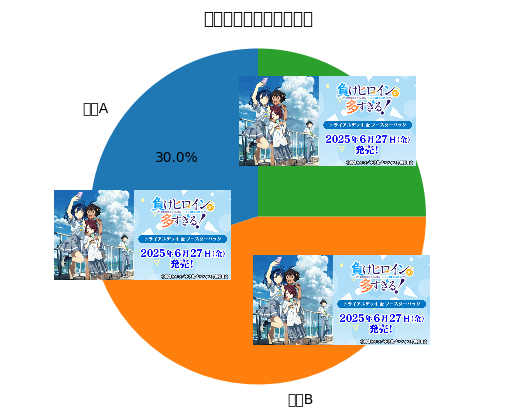

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np
import os

import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  # 設定黑體（SimHei）支援中文
plt.rcParams['axes.unicode_minus'] = False    # 正確顯示負號

# 假設你有三個系列，每個系列一張代表圖片
labels = ['系列A', '系列B', '系列C']
sizes = [30, 45, 25]
image_paths = [os.path.join('bottleneko_series', 'test.jpg'),
    os.path.join('bottleneko_series', 'test.jpg'),
    os.path.join('bottleneko_series', 'test.jpg')]  # 這裡放上你的圖片路徑

fig, ax = plt.subplots()
wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

# 計算每個區塊的中心角度
angles = np.cumsum([0]+sizes)
angles = (angles[:-1] + angles[1:]) / 2
angles = angles * 360 / sum(sizes)

# 在每個區塊上放圖片
for i, (wedge, angle, img_path) in enumerate(zip(wedges, angles, image_paths)):
    # 計算圖片放置位置（圓心為(0,0)，半徑約0.7）
    x = 0.7 * np.cos(np.deg2rad(angle))
    y = 0.7 * np.sin(np.deg2rad(angle))
    img = mpimg.imread(img_path)
    imagebox = OffsetImage(img, zoom=0.2)  # zoom可調整圖片大小
    ab = AnnotationBbox(imagebox, (x, y), frameon=False)
    ax.add_artist(ab)

plt.axis('equal')
plt.title('牌組系列分佈（含圖片）')
plt.show()


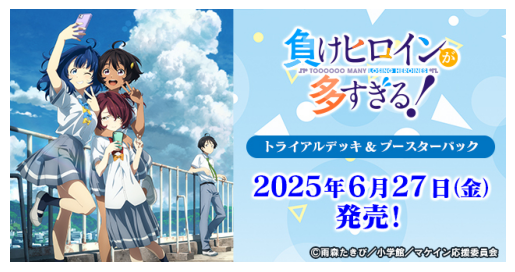

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

img_path = os.path.join('bottleneko_series', 'test.jpg')
if os.path.exists(img_path):
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print(f"圖片不存在: {img_path}")



/var/folders/ww/xnsh997j50x9dy529wrwvtq00000gn/T/ipykernel_43774/1979573861.py:26: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ww/xnsh997j50x9dy529wrwvtq00000gn/T/ipykernel_43774/1979573861.py:26: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


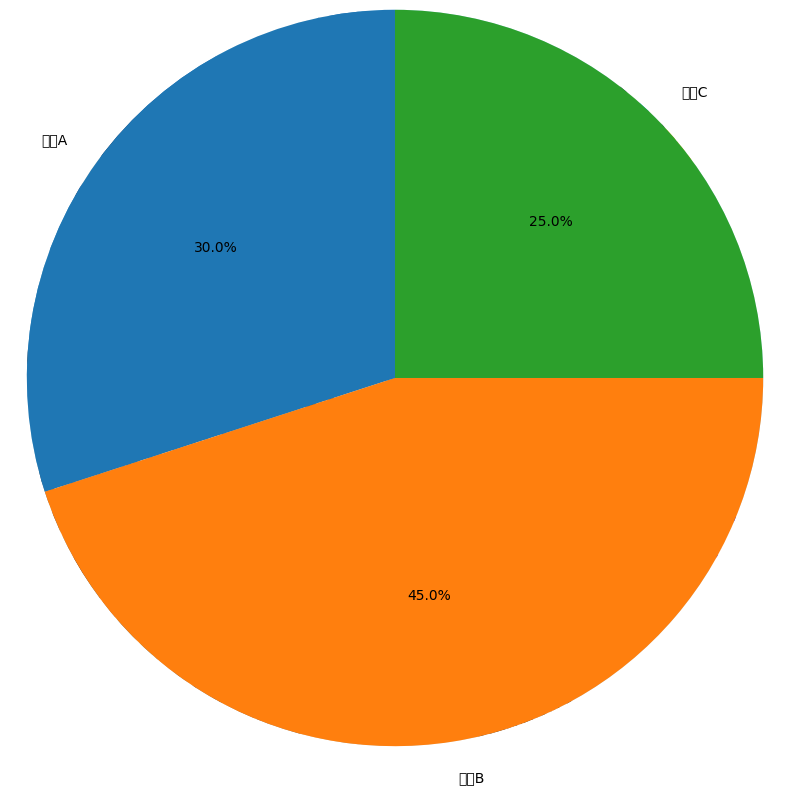

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os

labels = ['系列A', '系列B', '系列C']
sizes = [30, 45, 25]
image_paths = [os.path.join('bottleneko_series', 'test.jpg'),
    os.path.join('bottleneko_series', 'test.jpg'),
    os.path.join('bottleneko_series', 'test.jpg')]  # 這裡放上你的圖片路徑


fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

# 疊加圖片到每個 wedge
for i, (wedge, img_path) in enumerate(zip(wedges, image_paths)):
    if not os.path.exists(img_path):
        print(f"圖片不存在: {img_path}")
        continue
    img = mpimg.imread(img_path)
    # extent=[-1,1,-1,1] 讓圖片覆蓋整個圓餅
    ax.imshow(img, extent=[-1, 1, -1, 1], zorder=0, clip_path=wedge, clip_on=True)

plt.axis('equal')
plt.tight_layout()
plt.show()


# 抓系列名

In [72]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import time
import random

# 牌組代碼列表
deck_codes = ["X8SA","3NLU0","37PB6", "3KHCE", "5J67C", "2QL1Y", "48GVL","42UV8","6AJ3C","208D6","5DU6U","6ZJFG","7A5QE","2817A","2S3Qg","34JAU","63QLC"]

# 強化瀏覽器設定
chrome_options = webdriver.ChromeOptions()
chrome_options.add_argument('--headless')
chrome_options.add_argument('--disable-gpu')
chrome_options.add_argument('--no-sandbox')
chrome_options.add_argument('user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36')

service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=chrome_options)

# 處理 Cookie 同意彈窗的函數
def handle_cookie_consent(driver):
    try:
        # 等待 Cookie 同意按鈕出現 (最多等 5 秒)
        consent_button = WebDriverWait(driver, 5).until(
            EC.element_to_be_clickable((By.XPATH, '//button[text()="Allow all"]'))
        )
        consent_button.click()
        print("✅ 已自動點擊 Allow all 按鈕")
        time.sleep(2)  # 延長等待時間確保彈窗完全消失
        return True
    except Exception as e:
        print(f"ℹ️ 沒有發現 Cookie 彈窗或已自動關閉: {str(e)}")
        return False

results = []

try:
    # 特殊處理第一筆資料，先處理 Cookie 再重載
    if deck_codes:
        first_code = deck_codes[0]
        print(f"🔍 處理第一筆資料 (Cookie 處理): {first_code}")
        
        url = f'https://decklog-en.bushiroad.com/ja/view/{first_code}'
        driver.get(url)
        
        # 處理 Cookie 同意彈窗
        cookie_handled = handle_cookie_consent(driver)
        
        # 如果處理了 Cookie，重新載入頁面
        if cookie_handled:
            print("🔄 重新載入頁面以獲取資料...")
            time.sleep(2)
            driver.get(url)
        
        # 開始抓取資料
        try:
            # 強化元素等待機制
            element = WebDriverWait(driver, 15).until(
                EC.visibility_of_element_located(
                    (By.XPATH, '//p[contains(@class,"preview-top-label-right")]/span')
                )
            )
            
            # 使用 textContent 獲取文字
            title = driver.execute_script(
                'return arguments[0].textContent.trim();', element
            )
            
            if title and len(title) > 0:
                results.append(title)
                print(f"✅ 成功抓取 {first_code}: {title}")
            else:
                print(f"⚠️ 空值內容 {first_code}")
                results.append(None)
        except Exception as e:
            print(f"❌ 抓取失敗 {first_code}: {str(e)}")
            results.append(None)
    
    # 處理其餘牌組代碼
    for code in deck_codes[1:]:
        try:
            # 隨機延遲防止封鎖
            time.sleep(random.uniform(2, 5))
            
            url = f'https://decklog-en.bushiroad.com/ja/view/{code}'
            driver.get(url)
            
            # 強化元素等待機制
            element = WebDriverWait(driver, 15).until(
                EC.visibility_of_element_located(
                    (By.XPATH, '//p[contains(@class,"preview-top-label-right")]/span')
                )
            )
            
            # 改用 textContent 獲取文字
            title = driver.execute_script(
                'return arguments[0].textContent.trim();', element
            )
            
            # 驗證結果有效性
            if title and len(title) > 0:
                results.append(title)
                print(f"✅ 成功抓取 {code}: {title}")
            else:
                print(f"⚠️ 空值內容 {code}")
                results.append(None)
            
        except Exception as e:
            print(f"❌ 抓取失敗 {code}: {str(e)}")
            results.append(None)
            
finally:
    driver.quit()

# 清理並輸出結果
final_results = [x for x in results if x]
print("\n最終有效結果：")
print(final_results)


🔍 處理第一筆資料 (Cookie 處理): X8SA
✅ 已自動點擊 Allow all 按鈕
🔄 重新載入頁面以獲取資料...
✅ 成功抓取 X8SA: リコリス・リコイル
✅ 成功抓取 3NLU0: リコリス・リコイル
✅ 成功抓取 37PB6: リコリス・リコイル
✅ 成功抓取 3KHCE: デート・ア・ライブ
✅ 成功抓取 5J67C: BanG Dream!
✅ 成功抓取 2QL1Y: リコリス・リコイル
✅ 成功抓取 48GVL: 【推しの子】
✅ 成功抓取 42UV8: ラブライブ！虹ヶ咲学園スクールアイドル同好会
✅ 成功抓取 6AJ3C: ガールズバンドクライ
✅ 成功抓取 208D6: To LOVEる
✅ 成功抓取 5DU6U: 五等分の花嫁
✅ 成功抓取 6ZJFG: ラブライブ！虹ヶ咲学園スクールアイドル同好会
✅ 成功抓取 7A5QE: ラブライブ！虹ヶ咲学園スクールアイドル同好会
✅ 成功抓取 2817A: 甘神さんちの縁結び
✅ 成功抓取 2S3Qg: ゆらぎ荘の幽奈さん
✅ 成功抓取 34JAU: ぼっち・ざ・ろっく！
✅ 成功抓取 63QLC: ぼっち・ざ・ろっく！

最終有效結果：
['リコリス・リコイル', 'リコリス・リコイル', 'リコリス・リコイル', 'デート・ア・ライブ', 'BanG Dream!', 'リコリス・リコイル', '【推しの子】', 'ラブライブ！虹ヶ咲学園スクールアイドル同好会', 'ガールズバンドクライ', 'To LOVEる', '五等分の花嫁', 'ラブライブ！虹ヶ咲学園スクールアイドル同好会', 'ラブライブ！虹ヶ咲学園スクールアイドル同好会', '甘神さんちの縁結び', 'ゆらぎ荘の幽奈さん', 'ぼっち・ざ・ろっく！', 'ぼっち・ざ・ろっく！']


處理中: BanG Dream!
✅ 成功儲存圖片: series_images/series_1.jpg
處理中: To LOVEる
✅ 成功儲存圖片: series_images/series_2.jpg
處理中: 【推しの子】
✅ 成功儲存圖片: series_images/series_3.jpg
處理中: ぼっち・ざ・ろっく！
✅ 成功儲存圖片: series_images/series_4.jpg
處理中: ゆらぎ荘の幽奈さん
✅ 成功儲存圖片: series_images/series_5.jpg
處理中: ガールズバンドクライ
✅ 成功儲存圖片: series_images/series_6.jpg
處理中: デート・ア・ライブ
✅ 成功儲存圖片: series_images/series_7.jpg
處理中: ラブライブ！虹ヶ咲学園スクールアイドル同好会
✅ 成功儲存圖片: series_images/series_8.jpg
處理中: リコリス・リコイル
✅ 成功儲存圖片: series_images/series_9.jpg
處理中: 五等分の花嫁
✅ 成功儲存圖片: series_images/series_10.jpg
處理中: 甘神さんちの縁結び
✅ 成功儲存圖片: series_images/series_11.jpg
圖片爬取完成


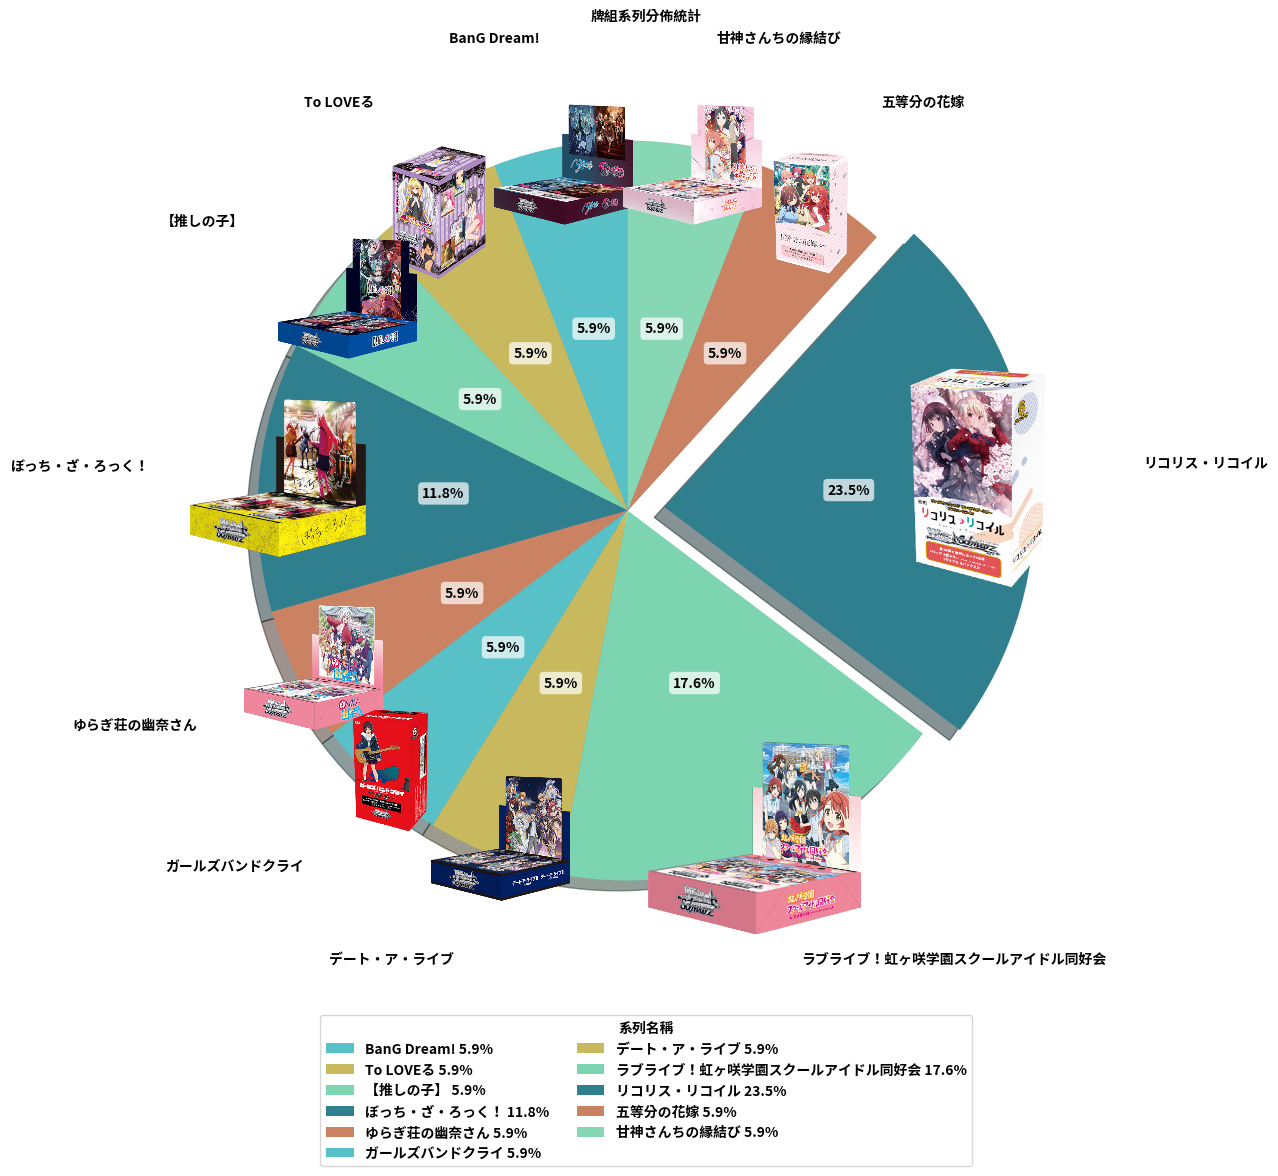

已刪除資料夾 series_images 中所有檔案


In [81]:
import os
import time
import random
import urllib.parse
import requests
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib as mpl
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import NoSuchElementException
import glob

def delete_all_files_in_directory(directory_path):
    files = glob.glob(os.path.join(directory_path, '*'))
    for file in files:
        if os.path.isfile(file):
            os.remove(file)
    print(f"已刪除資料夾 {directory_path} 中所有檔案")

# 1. 統計並排序系列
series_count = Counter(final_results)
unique_series = sorted(series_count.keys())

# 2. 建立系列名→英文檔名對應字典
def safe_english_filename(s):
    s_ascii = re.sub(r'[^\w]', '_', s)
    return s_ascii.lower()

series_to_filename = {}
for i, series in enumerate(unique_series):
    safe_name = f"series_{i+1}"
    series_to_filename[series] = safe_name

# 3. 建立資料夾
os.makedirs('series_images', exist_ok=True)

# 4. 下載圖片（只針對不重複系列，且跳過預組商品）
options = webdriver.ChromeOptions()
options.add_argument("--headless=new")
options.add_argument("--disable-gpu")
options.add_argument("--disable-blink-features=AutomationControlled")
options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36")
driver = webdriver.Chrome(options=options)

try:
    for series_name in unique_series:
        try:
            encoded_name = urllib.parse.quote(series_name)
            url = f"https://ws-tcg.com/products/?title={encoded_name}"
            print(f"處理中: {series_name}")
            driver.get(url)
            wait = WebDriverWait(driver, 10)
            product_list = wait.until(
                EC.presence_of_element_located((By.CSS_SELECTOR, "ul.product-list"))
            )
            # === 只抓第一個非預組商品的圖片 ===
            img_src = None
            for item in product_list.find_elements(By.CSS_SELECTOR, "li"):
                try:
                    category_label = item.find_element(By.CSS_SELECTOR, "p.category-label span").text
                    if "トライアルデッキ" in category_label:
                        continue  # 跳過預組商品
                    # 找到非預組商品的圖片
                    img = item.find_element(By.CSS_SELECTOR, "img")
                    img_src = img.get_attribute("src")
                    break
                except Exception:
                    continue
            if img_src:
                english_filename = series_to_filename[series_name]
                file_path = os.path.join('series_images', f"{english_filename}.jpg")
                if not os.path.exists(file_path):
                    response = requests.get(img_src)
                    if response.status_code == 200:
                        with open(file_path, 'wb') as file:
                            file.write(response.content)
                        print(f"✅ 成功儲存圖片: {file_path}")
                    else:
                        print(f"❌ 圖片下載失敗: HTTP {response.status_code}")
                else:
                    print(f"✓ 圖片已存在，略過：{file_path}")
            else:
                print(f"⚠️ 找不到非預組商品圖片: {series_name}")
        except Exception as e:
            print(f"❌ 處理失敗 ({series_name}): {str(e)}")
        time.sleep(random.uniform(1, 3))
finally:
    driver.quit()
    print("圖片爬取完成")

# 5. 畫圓餅圖
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Noto Sans CJK TC', 'Noto Sans CJK JP']
mpl.rcParams['axes.unicode_minus'] = False
font_path = 'font/NotoSansCJKtc-Bold.otf'
font_prop = fm.FontProperties(fname=font_path)

sizes = [series_count[s] for s in unique_series]
labels = unique_series

# 顏色循環，最後一個顏色特別處理
base_colors = ['#57c1c7', '#c9b95e', '#7dd4b1', '#2f7f8e', '#cb8262']
colors = [base_colors[i % len(base_colors)] for i in range(len(labels))]
if len(labels) > 1:
    colors[-1] = '#88D7B4'

explode = [0.1 if count == max(sizes) else 0 for count in sizes]
percent_labels = [f"{label} {size / sum(sizes) * 100:.1f}%" for label, size in zip(labels, sizes)]

fig, ax = plt.subplots(figsize=(14, 12))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=explode,
    shadow=True,
    textprops={'fontsize': 50, 'fontweight': 'bold', 'fontproperties': font_prop},
    labeldistance=1.3,
    pctdistance=0.5
)

# 百分比加白色網底
for autotext in autotexts:
    autotext.set_bbox(dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3', alpha=0.7))

plt.title('牌組系列分佈統計',
          fontsize=50,
          fontweight='bold',
          fontproperties=font_prop,
          pad=60)
plt.axis('equal')

legend = plt.legend(
    wedges, percent_labels,
    title="系列名稱",
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    prop=font_prop,
    borderaxespad=0.,
    title_fontsize=18
)

legend.get_title().set_fontproperties(font_prop)
# 計算各扇形中心角度以放置圖片 - 用 wedge 物件確保正確
wedge_angles = []
for wedge in wedges:
    theta1, theta2 = wedge.theta1, wedge.theta2
    mid_angle = np.radians((theta1 + theta2)/2)
    wedge_angles.append(mid_angle)

# 動態調整圖片大小，比例越大圖片越大
max_zoom = 0.45
min_zoom = 0.25
size_arr = np.array(sizes)
zoom_arr = min_zoom + (max_zoom - min_zoom) * (size_arr - size_arr.min()) / (size_arr.max() - size_arr.min() + 1e-8)

# 添加圖片到圓餅圖周圍（無背景無外框，佔比<5%不顯示）
for i, (series, angle, zoom) in enumerate(zip(labels, wedge_angles, zoom_arr)):
    percentage = (sizes[i] / sum(sizes)) * 100
    if percentage < 5:
        print(f"⏩ 跳過 {series} (佔比 {percentage:.1f}% < 5%)")
        continue

    english_filename = series_to_filename[series]
    img_path = os.path.join('series_images', f"{english_filename}.jpg")
    if os.path.exists(img_path):
        img_radius = 0.95
        x = img_radius * np.cos(angle)
        y = img_radius * np.sin(angle)
        try:
            img = mpimg.imread(img_path)
            imagebox = OffsetImage(img, zoom=zoom)
            ab = AnnotationBbox(
                imagebox, (x, y),
                frameon=False,
                pad=0
            )
            ax.add_artist(ab)
        except Exception as e:
            print(f"❌ 無法添加 {series} 的圖片: {str(e)}")

plt.tight_layout()
plt.savefig('deck_series_distribution_with_images.png',
           dpi=300,
           bbox_inches='tight',
           pad_inches=0.4)
plt.show()
delete_all_files_in_directory('series_images')


In [25]:
series_to_filename

{'BanG Dream!': 'series_1',
 'To LOVEる': 'series_2',
 '【推しの子】': 'series_3',
 'ガールズバンドクライ': 'series_4',
 'デート・ア・ライブ': 'series_5',
 'ラブライブ！虹ヶ咲学園スクールアイドル同好会': 'series_6',
 'リコリス・リコイル': 'series_7',
 '五等分の花嫁': 'series_8'}